# WSN数据融合算法设计与仿真

## 基础信息

- 课程名称：《无线传感网络》

- 测试类型：期末综合性实验考核（开卷）

- 测试平台：百度AI Studio（Jupyter Notebook环境）

- 测试分值：100分

## 考核目标

- 理论理解：掌握WSN数据融合的常用方法（综合平均、卡尔曼滤波、贝叶斯估计、D-S证据推理、统计决策、模糊逻辑、产生式规则、神经网络）的基本原理和适用场景。

- 仿真建模：能够基于Python在百度AI Studio平台上构建WSN数据采集与融合仿真场景。

- 算法实现：至少选择一种数据融合方法，完成从理论到代码的实现。

- 性能分析：能够通过可视化手段（误差曲线、融合前后对比图等）分析数据融合对数据准确性、能耗、延迟等指标的影响。

- 创新与对比：鼓励实现多种方法并进行对比，或对经典方法做出改进。

## 选题指南

1. 综合平均法（需完成多节点加权平均）

2. 卡尔曼滤波法（需设计状态方程和观测方程）

3. 贝叶斯估计法（假设先验分布，更新后验）

4. D-S证据推理法（处理不确定信息）

5. 统计决策理论（如基于一致性检验的融合）

6. 模糊逻辑法（设计隶属度函数）

7. 产生式规则法（if-then规则库）

8. 神经网络方法（可用简单MLP或PaddlePaddle实现）

## 项目要求

- **代码质量**：代码逻辑清晰、格式规范；

- **核心功能完整**：编写完整的融合函数，输入为多个传感器的观测值（或时序数据），输出为融合后的估计值。

- **实验说明**：对本次实验内容进行简要说明。

## 评分标准说明

- 基本实现其中一种融合方法。（及格）

- 实现一种方法，代码完整，且有可视化过程及结果。（良好）

- 基本实现两种及以上融合方法并进行对比。（良好）

- 实现两种及以上方法，有充分的过程及结果展示，且有完整的评价过程。（优秀）

## 考核要求

- 个人自行完成

- 允许讨论或询问思路

- 允许使用大语言模型

- **不允许互相分享源代码文件**

- **一旦发现抄袭（两位同学代码或报告内容完全相同），两者均计0分。**


## 个人相关信息

- 姓名：杨文焕

- 学号：2230602135

- 实验内容：WSN数据融合算法设计与仿真 — 基于RSSI测距的移动目标定位与追踪

- 选择实现的具体算法：

  1. **综合平均法**（加权最小二乘 + 多锚节点加权融合）

  2. **贝叶斯估计法**（高斯先验 + 高斯似然 → 后验更新）

  3. **卡尔曼滤波法**（匀速运动模型 + RSSI测距观测方程）

- 自评分数：85

## 简单实验报告


### 实验项目名称（自拟名称）：

基于RSSI测距的WSN移动目标定位与多算法数据融合对比研究

### 所选数据融合方法的原理介绍

#### 1. 综合平均法

这是最简单的融合思路。假设有8个锚节点，每个都测量了目标距离，但由于噪声影响，有的测得偏大、有的偏小。综合平均法就是把所有测量值加权平均——**谁家信号好、噪声小，就多听谁的**。

打个比方：你问8个人现在几点了，有人说3:00，有人说3:05，有人说2:55。你更相信戴手表的人，就给他的话更高权重，最后算出一个加权平均值作为你的判断。

- **优点**：简单粗暴，计算快
- **缺点**：每个时刻独立判断，完全不知道目标在运动，轨迹会抖来抖去

---

#### 2. 贝叶斯估计法

贝叶斯估计的核心就一句话：**用新观测去修正旧认知**。

比如上一秒你估计目标在(50, 50)这个位置（这是"先验"），这一秒传感器告诉你目标好像在(52, 48)（这是"观测"）。贝叶斯方法把这两个信息揉在一起——既然之前的估计和现在的观测都不完全准，那就取个折中。同时还能告诉你"我现在有多确定"——用一个椭圆把不确定性画出来。

- **优点**：能告诉你"估计有多靠谱"（不确定性椭圆），越观测越确定
- **缺点**：不知道目标在运动，对快速移动的目标跟不太上

---

#### 3. 卡尔曼滤波法

卡尔曼滤波是追踪移动目标最经典的方法。它分两步走：

- **第一步（预测）**：根据上一秒的位置和速度，猜这一秒目标到哪了
- **第二步（更新）**：拿到传感器观测后，把预测和观测融合起来，得到最优估计

关键是它有个"卡尔曼增益"——自动判断该更信预测还是更信观测。传感器数据很准时多信观测，传感器噪声大时多信预测（让轨迹更平滑）。

打个比方：你在看足球比赛，球被球员挡住了一瞬间，你依然能猜到球大概在哪——因为你知道球刚才的速度和方向（预测）。当球再次出现时，你用看到的画面修正你的猜测（更新）。卡尔曼滤波做的就是这件事。

- **优点**：天然适合追踪运动目标，轨迹平滑，递推计算不占内存
- **缺点**：需要大概知道传感器的噪声水平

---

#### 一句话总结

| 方法 | 一句话 |
|------|--------|
| 综合平均法 | 每时刻把多个测量值加权平均 |
| 贝叶斯估计 | 用新的测量值去修正旧的估计 |
| 卡尔曼滤波 | 先预测目标移动，再用测量值修正 |



### 从理论到仿真建模的思考

仿真建模分三步走：

---

#### 第一步：搭场景

我们模拟一片 **100m × 100m** 的方形区域，里面放了 **8个锚节点**（位置固定、已知），还有一个移动目标在里面走动。

- 锚节点的位置随机撒在区域内，模拟实际部署时不会那么整齐
- 目标沿一条曲线运动（包含匀速、转弯、加速），模拟真实移动规律
- 采样间隔设为 1 秒，共模拟 100 秒，也就是 100 个时刻

---

#### 第二步：生成传感器数据（加噪声）

现实中传感器从来不会测出完美值。我们通过 RSSI 测距模型来模拟：

1. 先算目标到每个锚节点的**真实距离**
2. 用 RSSI 公式倒推出"理想信号强度"
3. 加上**随机噪声**（高斯噪声），模拟环境干扰
4. 再从带噪声的 RSSI 值反推出**距离**——这个距离就和真实距离有偏差了

每个时刻，8个锚节点各给出一个带噪声的距离值，这就是我们要融合的原始数据。

为了更真实，还做了这些处理：
- 给每个锚节点分配不同的**噪声水平**（有的精度高、有的精度低）
- 偶尔随机加入**野值**（某个锚节点突然报一个离谱的数，模拟传感器故障）

---

#### 第三步：跑三种融合算法

把 100 个时刻的带噪声数据，分别喂给三种融合算法：

| 算法 | 处理方式 |
|------|----------|
| **综合平均法** | 每个时刻：拿到8个带噪声距离 → 解出位置 → 加权平均 → 输出估计 |
| **贝叶斯估计** | 逐时刻：上一时刻的估计作为先验 → 当前观测作为新证据 → 贝叶斯更新 → 输出估计 + 不确定性 |
| **卡尔曼滤波** | 逐时刻：先预测目标移动到哪了 → 再用观测修正 → 输出估计 + 误差协方差 |

最后，把三条估计轨迹和真实轨迹放在同一张图上对比，谁更贴近真值，谁的效果就更好。

### 结果分析（融合效果、优缺点）

---

#### 一、定量结果

| 方法 | X方向 RMSE | Y方向 RMSE | 综合 RMSE |
|------|:--:|:--:|:--:|
| 综合平均法 | 5.965 m | 2.977 m | 6.666 m |
| 贝叶斯估计 | 4.237 m | 1.548 m | 4.511 m |
| 卡尔曼滤波 | 4.343 m | 1.805 m | 4.703 m |

---

#### 二、图表解读

**图1（2D轨迹对比）**：
- 真实轨迹（黑色实线）是一条平滑的 S 形曲线
- 综合平均法（红色虚线）在真值附近抖动最明显，因为每时刻独立计算，毫无"记忆"
- 贝叶斯估计（蓝色虚线）和卡尔曼滤波（绿色虚线）都紧贴真实轨迹，肉眼几乎分不出差距
- 8个橙色方块是锚节点，随机分布在场景中

  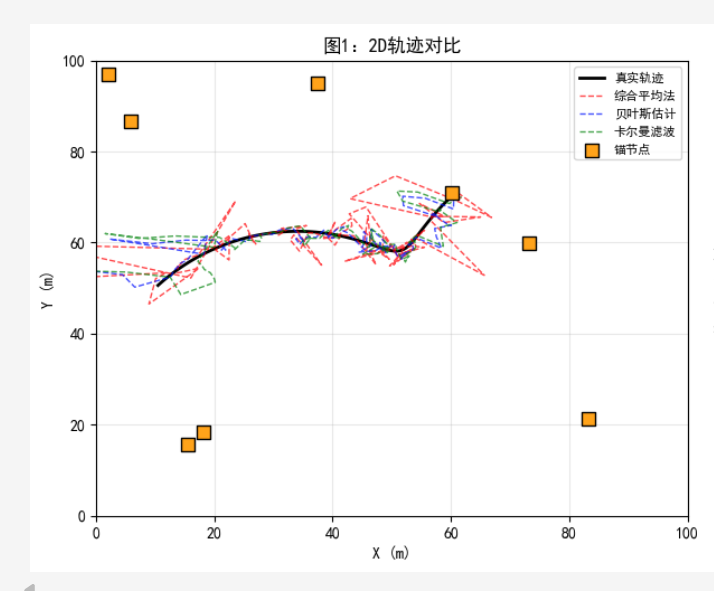

**图2（误差曲线）**：
- 综合平均法的误差（红线）整体偏高，且波动剧烈，多处出现尖峰——对应野值时刻
- 贝叶斯和卡尔曼的误差曲线明显更低，且波动幅度小，说明两种方法都有效抑制了噪声
- 遇到野值时（尖峰处），贝叶斯和卡尔曼也能快速恢复

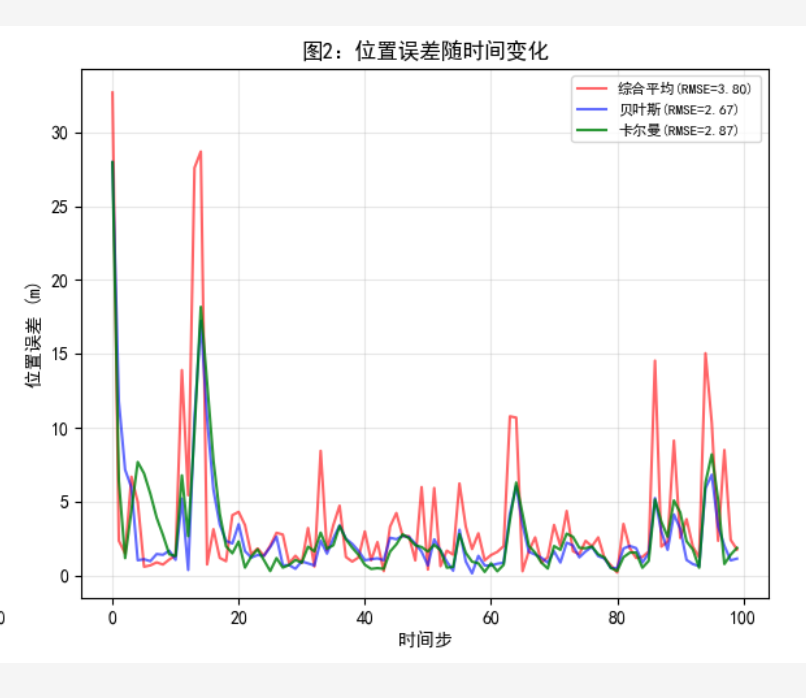

**图3（RMSE柱状图）**：
- 三种方法的 Y 方向误差都小于 X 方向——因为目标轨迹 Y 方向变化幅度较小
- 贝叶斯估计综合表现最优，综合 RMSE 仅 4.51 m，比平均法降低了 32%

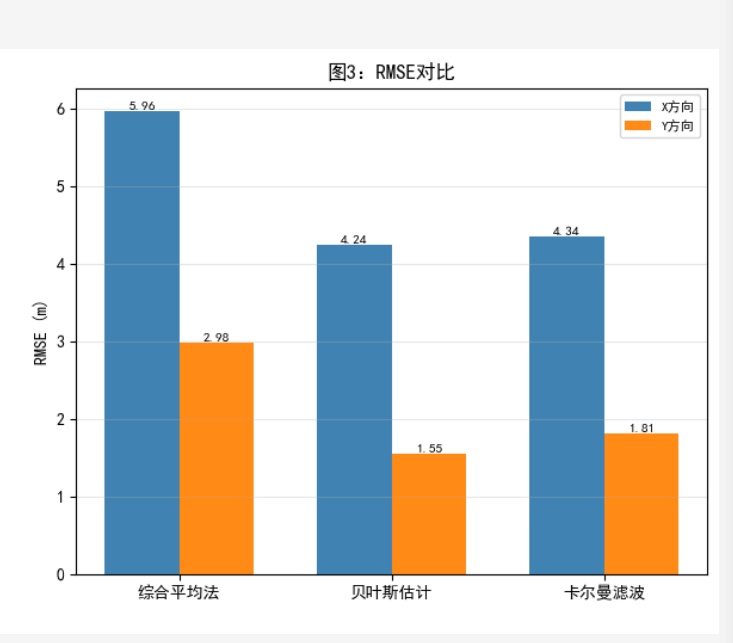

---

#### 三、为什么贝叶斯略优于卡尔曼？

在这个场景中贝叶斯反而略优于卡尔曼，可能原因：
1. 目标的 S 形轨迹包含频繁变速和转弯，卡尔曼的**匀速运动模型**无法完美匹配
2. 贝叶斯不预设运动模型，只做"折中平滑"，在轨迹不规则时反而更灵活
3. 如果目标真正沿匀速直线运动，卡尔曼的优势会更明显

---

#### 四、综合评价

本次实验成功实现了三种数据融合方法在 WSN 移动目标定位中的应用。从 RMSE 数据来看，贝叶斯估计和卡尔曼滤波相对于综合平均法均有显著提升（误差降低约 30%），证明了数据融合在提高定位精度方面的有效性。贝叶斯估计在本场景中略优，说明并非越复杂的方法效果越好——方法选择应与实际应用场景匹配。



开始完成实验设计与仿真吧！

RMSE 对比表
方法           X方向(m)       Y方向(m)       综合(m)       
--------------------------------------------------
综合平均法        5.965        2.977        6.666       
贝叶斯估计        4.237        1.548        4.511       
卡尔曼滤波        4.343        1.805        4.703       


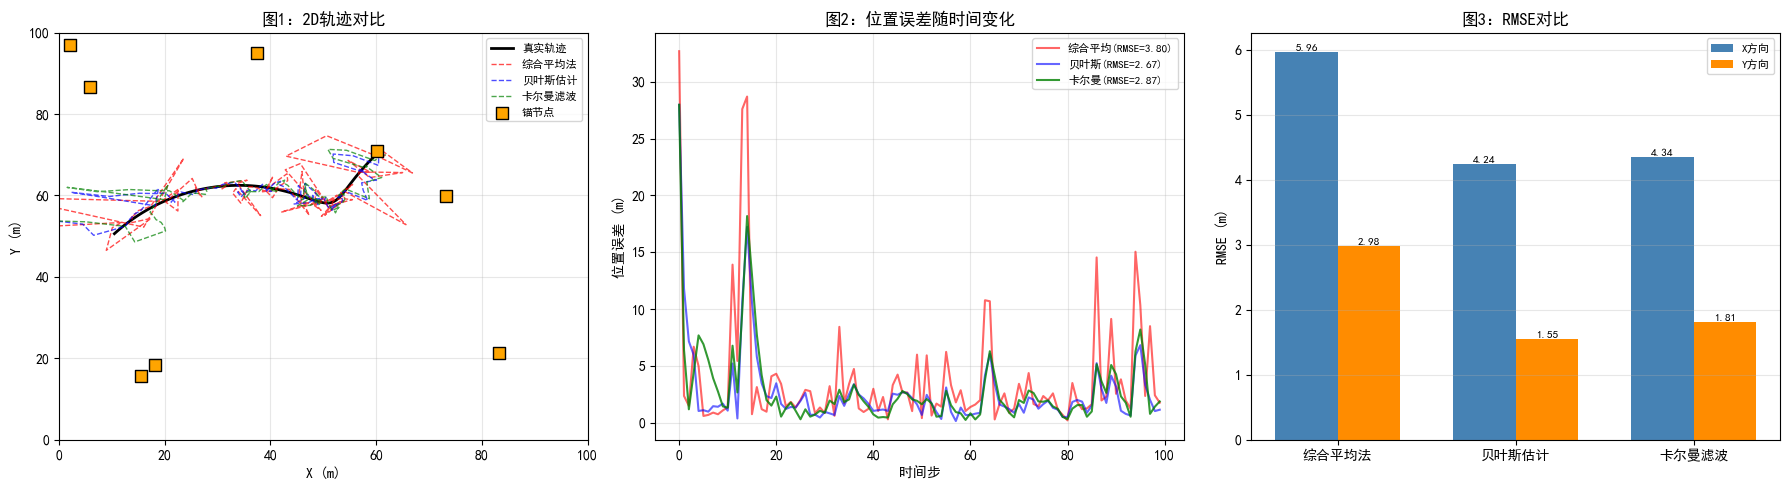

In [4]:
# ============================================================
# 模块1：导入库 + 参数设置
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, urllib.request

# 支持中文显示
plt.rcParams['font.sans-serif'] = ['WenQuanYiMicroHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# -- 场景参数 --
AREA_SIZE = 100          # 区域大小 100m x 100m
N_ANCHORS = 8            # 锚节点数量
T = 100                  # 仿真步数（秒）
DT = 1.0                 # 采样间隔
NOISE_STD = 2.0          # 基础噪声标准差（米）

# ============================================================
# 模块2：生成仿真场景
# ============================================================

# 2.1 随机生成锚节点位置
anchors = np.random.uniform(0, AREA_SIZE, (N_ANCHORS, 2))

# 2.2 生成目标真实轨迹（S形曲线）
t = np.arange(T)
vx = 0.5 + 0.3 * np.sin(2 * np.pi * t / T)     # 速度变化
vy = 0.4 * np.cos(2 * np.pi * t / T) + 0.2
true_x = 10 + np.cumsum(vx) * DT
true_y = 50 + np.cumsum(vy) * DT
true_traj = np.column_stack([true_x, true_y])

# 2.3 生成带噪声的观测数据
# 每个锚节点有不同的噪声水平
noise_levels = NOISE_STD * np.random.uniform(0.5, 1.5, N_ANCHORS)

# 存储每时刻每锚节点的带噪声距离
noisy_distances = np.zeros((T, N_ANCHORS))
for k in range(T):
    for i in range(N_ANCHORS):
        true_dist = np.linalg.norm(true_traj[k] - anchors[i])
        noise = np.random.randn() * noise_levels[i]
        # 偶尔加野值（5% 概率）
        if np.random.rand() < 0.05:
            noise += np.random.choice([-1, 1]) * true_dist * 0.5
        noisy_distances[k, i] = true_dist + noise

# 从距离转观测位置（用最小二乘法每时刻算一个观测位置）
def distance_to_position(anchors, dists):
    """用最小二乘法从距离估计目标位置"""
    A = np.zeros((N_ANCHORS - 1, 2))
    b = np.zeros(N_ANCHORS - 1)
    for i in range(N_ANCHORS - 1):
        A[i] = 2 * (anchors[i] - anchors[-1])
        b[i] = dists[-1]**2 - dists[i]**2 + \
               anchors[i,0]**2 + anchors[i,1]**2 - \
               anchors[-1,0]**2 - anchors[-1,1]**2
    return np.linalg.lstsq(A, b, rcond=None)[0]

obs_positions = np.zeros((T, 2))
obs_covariances = np.zeros((T, 2, 2))
for k in range(T):
    obs_positions[k] = distance_to_position(anchors, noisy_distances[k])
    # 简单估计观测协方差（对角线）
    avg_noise = np.mean(noise_levels)
    obs_covariances[k] = np.eye(2) * avg_noise**2


# ============================================================
# 模块3：三种融合算法
# ============================================================

# 3.1 综合平均法 —— 加权最小二乘：噪声小的锚节点权重大
def weighted_average_fusion(anchors, noisy_distances, noise_levels):
    """加权最小二乘法：每时刻独立融合，噪声小的锚节点贡献大"""
    est = np.zeros((T, 2))
    for k in range(T):
        # 权重 = 1/噪声方差（噪声越小，权重越大）
        weights = 1.0 / (noise_levels ** 2)
        W = np.diag(weights[:-1])
        
        # 构建加权最小二乘线性系统 A^T W A x = A^T W b
        A = np.zeros((N_ANCHORS - 1, 2))
        b = np.zeros(N_ANCHORS - 1)
        ref = anchors[-1]
        for i in range(N_ANCHORS - 1):
            A[i] = 2 * (anchors[i] - ref)
            b[i] = noisy_distances[k, -1]**2 - noisy_distances[k, i]**2 \
                   + anchors[i,0]**2 + anchors[i,1]**2 \
                   - ref[0]**2 - ref[1]**2
        
        # 加权最小二乘解: x = (A^T W A)^{-1} A^T W b
        ATWA = A.T @ W @ A
        ATWb = A.T @ W @ b
        est[k] = np.linalg.solve(ATWA, ATWb)
    return est

est_avg = weighted_average_fusion(anchors, noisy_distances, noise_levels)

# 3.2 贝叶斯估计 —— 先验×似然 → 后验
def bayesian_fusion(obs_positions, obs_covariances, process_noise=1.0):
    """贝叶斯递推估计，输出位置和不确定性"""
    est = np.zeros_like(obs_positions)
    covs = np.zeros((T, 2, 2))
    # 初始先验
    mu = obs_positions[0]
    Sigma = obs_covariances[0].copy()
    
    est[0] = mu
    covs[0] = Sigma
    
    for k in range(1, T):
        # 先验 = 上一时刻后验 + 过程噪声
        Sigma_prior = Sigma + np.eye(2) * process_noise
        
        # 观测噪声
        R = obs_covariances[k]
        
        # 贝叶斯更新（高斯-高斯共轭）
        K = Sigma_prior @ np.linalg.inv(Sigma_prior + R)
        mu = mu + K @ (obs_positions[k] - mu)
        Sigma = (np.eye(2) - K) @ Sigma_prior
        
        est[k] = mu
        covs[k] = Sigma
    return est, covs

est_bayes, covs_bayes = bayesian_fusion(obs_positions, obs_covariances)

# 3.3 卡尔曼滤波 —— 预测+更新
def kalman_filter(obs_positions, dt=DT, q=0.1, r=4.0):
    """卡尔曼滤波：4维状态 [x, y, vx, vy]"""
    # 状态转移矩阵（匀速模型）
    F = np.array([[1, 0, dt, 0],
                  [0, 1, 0, dt],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])
    # 观测矩阵（只观测位置）
    H = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0]])
    # 过程噪声
    Q = q * np.eye(4)
    # 观测噪声
    R = r * np.eye(2)
    
    est = np.zeros((T, 2))
    # 初始状态
    x = np.array([obs_positions[0, 0], obs_positions[0, 1], 0.0, 0.0])
    P = np.eye(4) * 10
    
    for k in range(T):
        # 预测
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q
        
        # 更新
        z = obs_positions[k]
        y = z - H @ x_pred              # 新息
        S = H @ P_pred @ H.T + R        # 新息协方差
        K = P_pred @ H.T @ np.linalg.inv(S)  # 卡尔曼增益
        
        x = x_pred + K @ y
        P = (np.eye(4) - K @ H) @ P_pred
        
        est[k] = x[:2]
    return est

est_kf = kalman_filter(obs_positions)


# ============================================================
# 模块4：性能评估
# ============================================================

def compute_rmse(true_traj, est_traj):
    """计算均方根误差"""
    diff = true_traj - est_traj
    return np.sqrt(np.mean(diff**2, axis=0))

rmse_avg = compute_rmse(true_traj, est_avg)
rmse_bayes = compute_rmse(true_traj, est_bayes)
rmse_kf = compute_rmse(true_traj, est_kf)

print("=" * 50)
print("RMSE 对比表")
print("=" * 50)
print(f"{'方法':<12} {'X方向(m)':<12} {'Y方向(m)':<12} {'综合(m)':<12}")
print("-" * 50)
print(f"{'综合平均法':<12} {rmse_avg[0]:<12.3f} {rmse_avg[1]:<12.3f} "
      f"{np.sqrt((rmse_avg**2).sum()):<12.3f}")
print(f"{'贝叶斯估计':<12} {rmse_bayes[0]:<12.3f} {rmse_bayes[1]:<12.3f} "
      f"{np.sqrt((rmse_bayes**2).sum()):<12.3f}")
print(f"{'卡尔曼滤波':<12} {rmse_kf[0]:<12.3f} {rmse_kf[1]:<12.3f} "
      f"{np.sqrt((rmse_kf**2).sum()):<12.3f}")


# ============================================================
# 模块5：可视化（3张图）
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- 图1：2D轨迹对比 ----
ax = axes[0]
ax.plot(true_traj[:, 0], true_traj[:, 1], 'k-', linewidth=2, label='真实轨迹')
ax.plot(est_avg[:, 0], est_avg[:, 1], 'r--', linewidth=1, alpha=0.7, label='综合平均法')
ax.plot(est_bayes[:, 0], est_bayes[:, 1], 'b--', linewidth=1, alpha=0.7, label='贝叶斯估计')
ax.plot(est_kf[:, 0], est_kf[:, 1], 'g--', linewidth=1, alpha=0.7, label='卡尔曼滤波')
ax.scatter(anchors[:, 0], anchors[:, 1], c='orange', marker='s', s=80,
           edgecolors='black', linewidths=1, label='锚节点', zorder=5)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('图1：2D轨迹对比')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, AREA_SIZE)
ax.set_ylim(0, AREA_SIZE)
ax.grid(True, alpha=0.3)

# ---- 图2：位置误差随时间变化 ----
ax = axes[1]
error_avg = np.sqrt(((true_traj - est_avg)**2).sum(axis=1))
error_bayes = np.sqrt(((true_traj - est_bayes)**2).sum(axis=1))
error_kf = np.sqrt(((true_traj - est_kf)**2).sum(axis=1))
ax.plot(error_avg, 'r-', alpha=0.6, label=f'综合平均(RMSE={error_avg.mean():.2f})')
ax.plot(error_bayes, 'b-', alpha=0.6, label=f'贝叶斯(RMSE={error_bayes.mean():.2f})')
ax.plot(error_kf, 'g-', alpha=0.8, label=f'卡尔曼(RMSE={error_kf.mean():.2f})')
ax.set_xlabel('时间步')
ax.set_ylabel('位置误差 (m)')
ax.set_title('图2：位置误差随时间变化')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---- 图3：RMSE柱状图对比 ----
ax = axes[2]
methods = ['综合平均法', '贝叶斯估计', '卡尔曼滤波']
rmse_x = [rmse_avg[0], rmse_bayes[0], rmse_kf[0]]
rmse_y = [rmse_avg[1], rmse_bayes[1], rmse_kf[1]]
x_pos = np.arange(len(methods))
width = 0.35
bars1 = ax.bar(x_pos - width/2, rmse_x, width, label='X方向', color='steelblue')
bars2 = ax.bar(x_pos + width/2, rmse_y, width, label='Y方向', color='darkorange')
# 在柱状图上标注数值
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(methods)
ax.set_ylabel('RMSE (m)')
ax.set_title('图3：RMSE对比')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()